In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Charge le .env situé à la racine du projet (2 dossiers au-dessus de src/ml/)
load_dotenv(dotenv_path="../../.env")

# Confort d'affichage
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)          # afficher toutes les colonnes
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librairies importées ✅")


Librairies importées ✅


In [2]:
# Connexion à la base MySQL à partir des variables du .env
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# On récupère le nombre total de lignes (le vrai dataset complet)
total = pd.read_sql("SELECT COUNT(*) AS n FROM transactions;", con=engine)["n"][0]

# Pour l'EDA : échantillon aléatoire de 200 000 lignes (rapide et représentatif)
query = "SELECT * FROM transactions WHERE RAND() < 0.04 LIMIT 200000;"
df = pd.read_sql(query, con=engine)

print(f"Échantillon chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Dataset complet en base : {total:,} lignes")
df.head()


Échantillon chargé : 200,000 lignes × 23 colonnes
Dataset complet en base : 5,625,088 lignes


,Date mutation,Nature mutation,Valeur fonciere,Code postal,Commune,Code departement,Code commune,Type local,Surface reelle bati,Nombre pieces principales,Surface terrain,prix_m2,annee,mois,trimestre,code_commune_geo,nom_commune_geo,codeDepartement,codeRegion,population_geo,longitude,latitude,revenu_median
0,2021-01-13,Vente,"221,831.00","1,370.00",SAINT-ETIENNE-DU-BOIS,01,350,Maison,104.00,4.00,713.00,"2,132.99",2021,1,1,01350,Saint-Étienne-du-Bois,01,84.00,"2,584.00",5.28,46.28,"21,421.00"
1,2021-01-06,Vente,"158,000.00","1,250.00",HAUTECOURT-ROMANECHE,01,184,Maison,106.00,4.00,499.00,"1,490.57",2021,1,1,01184,Hautecourt-Romanèche,01,84.00,748.00,5.43,46.16,"20,989.00"
2,2021-01-12,Vente,"172,000.00","1,340.00",JAYAT,01,196,Maison,38.00,2.00,683.00,"4,526.32",2021,1,1,01196,Jayat,01,84.00,"1,261.00",5.11,46.37,"21,040.40"
3,2021-01-20,Vente,"200,000.00","1,000.00",SAINT-DENIS-LES-BOURG,01,344,Maison,91.00,5.00,602.00,"2,197.80",2021,1,1,01344,Saint-Denis-lès-Bourg,01,84.00,"6,160.00",5.18,46.21,"23,351.50"
4,2021-01-08,Vente,"201,400.00","1,370.00",BENY,01,38,Maison,104.00,5.00,614.00,"1,936.54",2021,1,1,01038,Bény,01,84.00,777.00,5.28,46.32,"21,310.00"


In [3]:
print("Dimensions :", df.shape, "\n")
df.info()


Dimensions : (200000, 23) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Date mutation              200000 non-null  datetime64[ns]
 1   Nature mutation            200000 non-null  object        
 2   Valeur fonciere            200000 non-null  float64       
 3   Code postal                200000 non-null  float64       
 4   Commune                    200000 non-null  object        
 5   Code departement           200000 non-null  object        
 6   Code commune               200000 non-null  int64         
 7   Type local                 200000 non-null  object        
 8   Surface reelle bati        200000 non-null  float64       
 9   Nombre pieces principales  200000 non-null  float64       
 10  Surface terrain            123918 non-null  float64       
 11  prix_m2                 

In [4]:
na = df.isna().sum()
na_pct = (na / len(df) * 100).round(2)

missing = pd.DataFrame({"nb_manquant": na, "pct_manquant": na_pct})
missing = missing[missing.nb_manquant > 0].sort_values("pct_manquant", ascending=False)

print("Colonnes avec valeurs manquantes :")
missing


Colonnes avec valeurs manquantes :


,nb_manquant,pct_manquant
Surface terrain,76082,38.04


In [5]:
# Variables numériques
print("=== Variables numériques ===")
display(df.describe())

# Variables catégorielles (texte)
print("\n=== Variables catégorielles ===")
display(df.describe(include=["object"]))


=== Variables numériques ===


,Date mutation,Valeur fonciere,Code postal,Code commune,Surface reelle bati,Nombre pieces principales,Surface terrain,prix_m2,annee,mois,trimestre,codeRegion,population_geo,longitude,latitude,revenu_median
count,200000,"200,000.00","200,000.00","200,000.00","200,000.00","200,000.00","123,918.00","200,000.00","200,000.00","200,000.00","200,000.00","200,000.00","200,000.00","200,000.00","200,000.00","200,000.00"
mean,2023-01-22 23:53:50.208000,"373,597.34","48,797.01",207.95,83.94,3.53,973.29,"5,626.28","2,022.55",6.68,2.55,54.86,"109,863.80",2.57,46.18,"20,494.17"
min,2021-01-02 00:00:00,"1,001.00","1,000.00",1.00,15.00,0.00,0.00,5.34,"2,021.00",1.00,1.00,2.00,65.00,-61.20,-21.33,"10,827.40"
25%,2021-12-07 00:00:00,"120,000.00","26,780.00",74.00,52.00,2.00,256.00,"1,658.13","2,021.00",4.00,2.00,28.00,"1,973.00",0.40,44.38,"18,380.60"
50%,2022-11-17 00:00:00,"195,000.00","45,200.00",170.00,77.00,3.00,500.00,"2,608.11","2,022.00",7.00,3.00,53.00,"8,443.00",2.38,46.79,"19,848.00"
75%,2024-02-09 00:00:00,"315,000.00","75,008.00",298.00,104.00,4.00,860.00,"4,186.05","2,024.00",10.00,4.00,76.00,"44,292.00",4.75,48.76,"21,856.80"
max,2025-12-31 00:00:00,"94,000,000.00","97,490.00",909.00,"1,775.00",80.00,"643,406.00","3,019,077.33","2,025.00",12.00,4.00,94.00,"2,103,778.00",55.74,51.07,"45,902.40"
std,NaN,"1,941,999.03","27,711.47",169.74,47.18,1.61,"6,087.96","37,542.65",1.28,3.37,1.09,28.43,"357,390.02",5.58,5.71,"3,334.14"



=== Variables catégorielles ===


,Nature mutation,Commune,Code departement,Type local,code_commune_geo,nom_commune_geo,codeDepartement
count,200000,200000,200000,200000,200000,200000,200000
unique,1,21811,95,2,22741,21676,95
top,Vente,TOULOUSE,13,Maison,75056,Paris,13
freq,200000,1872,6848,115111,5360,5360,6848


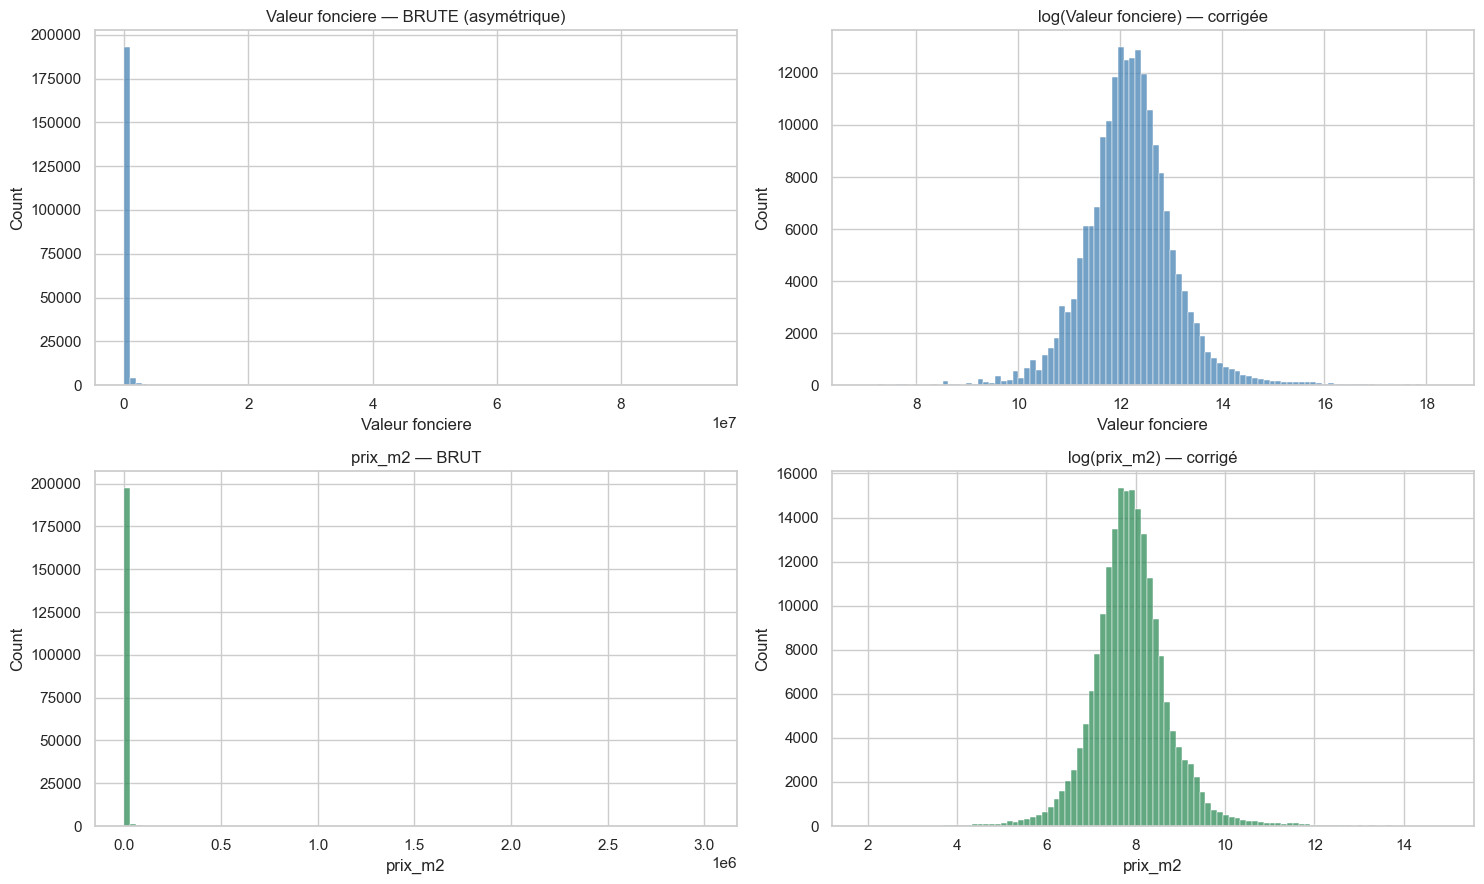

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# --- Valeur fonciere ---
sns.histplot(df["Valeur fonciere"], bins=100, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Valeur fonciere — BRUTE (asymétrique)")

sns.histplot(np.log1p(df["Valeur fonciere"]), bins=100, ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("log(Valeur fonciere) — corrigée")

# --- prix_m2 ---
sns.histplot(df["prix_m2"], bins=100, ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("prix_m2 — BRUT")

sns.histplot(np.log1p(df["prix_m2"]), bins=100, ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("log(prix_m2) — corrigé")

plt.tight_layout()
plt.show()


In [7]:
for col in ["Valeur fonciere", "prix_m2"]:
    skew_brut = df[col].skew()
    skew_log = np.log1p(df[col]).skew()
    print(f"{col:20s} | skew brut = {skew_brut:6.2f} | skew log = {skew_log:6.2f}")


Valeur fonciere      | skew brut =  28.01 | skew log =   0.31
prix_m2              | skew brut =  35.73 | skew log =   0.60


✅ Décision : on prédira Valeur fonciere, transformée en log

Pourquoi :

Skew log de 0,31 = le plus proche de 0 → distribution la plus « propre », donc la plus facile à apprendre pour un modèle.
C'est la cible la plus intuitive à présenter (« prédire le prix d'un bien »).
On appliquera np.log1p() sur la cible au moment de l'entraînement (notebook 04), et on repassera en euros avec np.expm1() pour l'évaluation. Je te guiderai là-dessus.

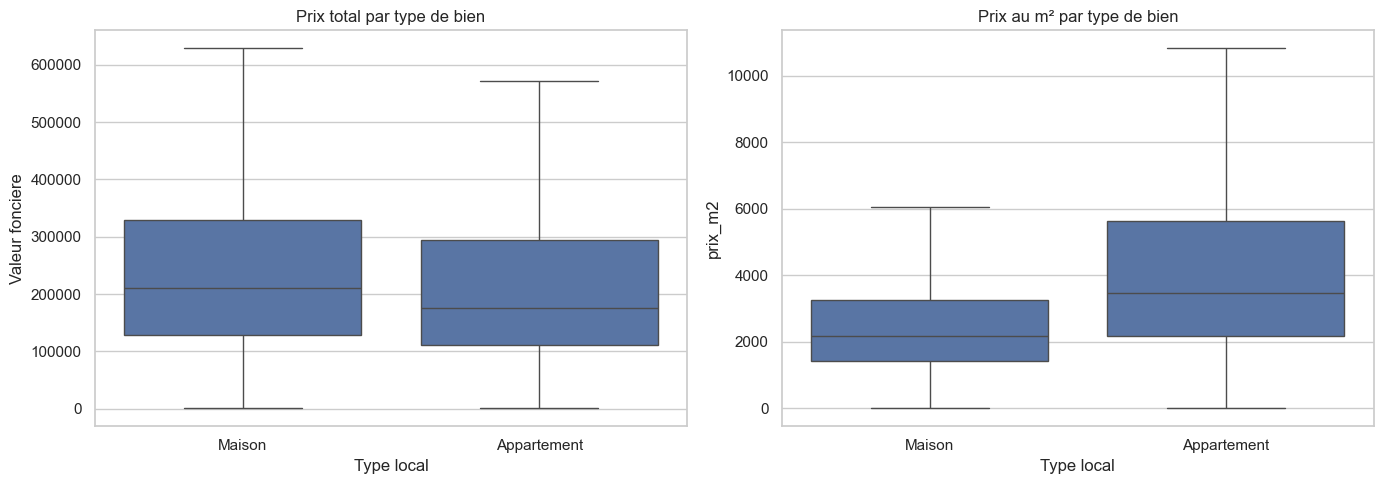

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prix total
sns.boxplot(data=df, x="Type local", y="Valeur fonciere", ax=axes[0], showfliers=False)
axes[0].set_title("Prix total par type de bien")

# Prix au m² (plus juste pour comparer)
sns.boxplot(data=df, x="Type local", y="prix_m2", ax=axes[1], showfliers=False)
axes[1].set_title("Prix au m² par type de bien")

plt.tight_layout()
plt.show()


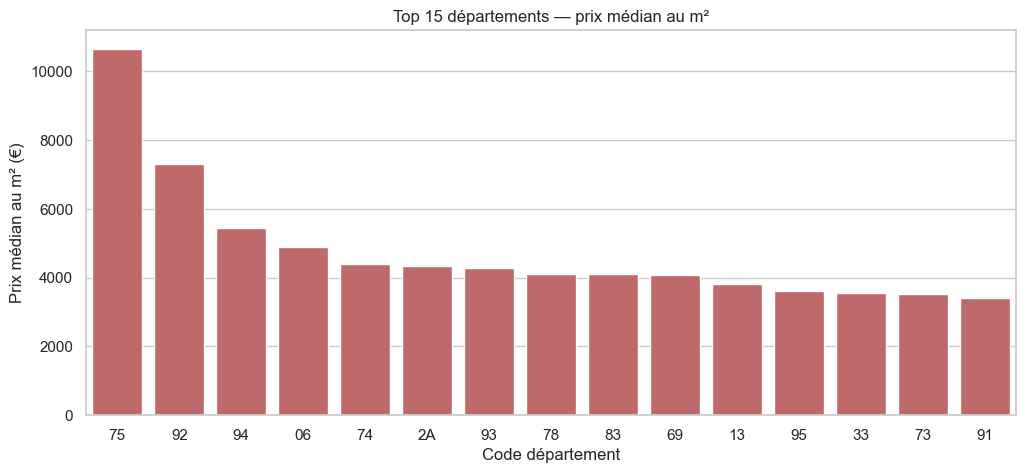

Code departement
75   10,666.67
92    7,294.12
94    5,441.18
06    4,904.30
74    4,409.55
2A    4,333.33
93    4,285.71
78    4,106.67
83    4,096.80
69    4,081.14
13    3,825.12
95    3,603.22
33    3,560.00
73    3,539.17
91    3,401.96
Name: prix_m2, dtype: float64

In [9]:
# Prix médian au m² par département
prix_dept = (
    df.groupby("Code departement")["prix_m2"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 5))
sns.barplot(x=prix_dept.index, y=prix_dept.values, color="indianred")
plt.title("Top 15 départements — prix médian au m²")
plt.xlabel("Code département")
plt.ylabel("Prix médian au m² (€)")
plt.show()

prix_dept


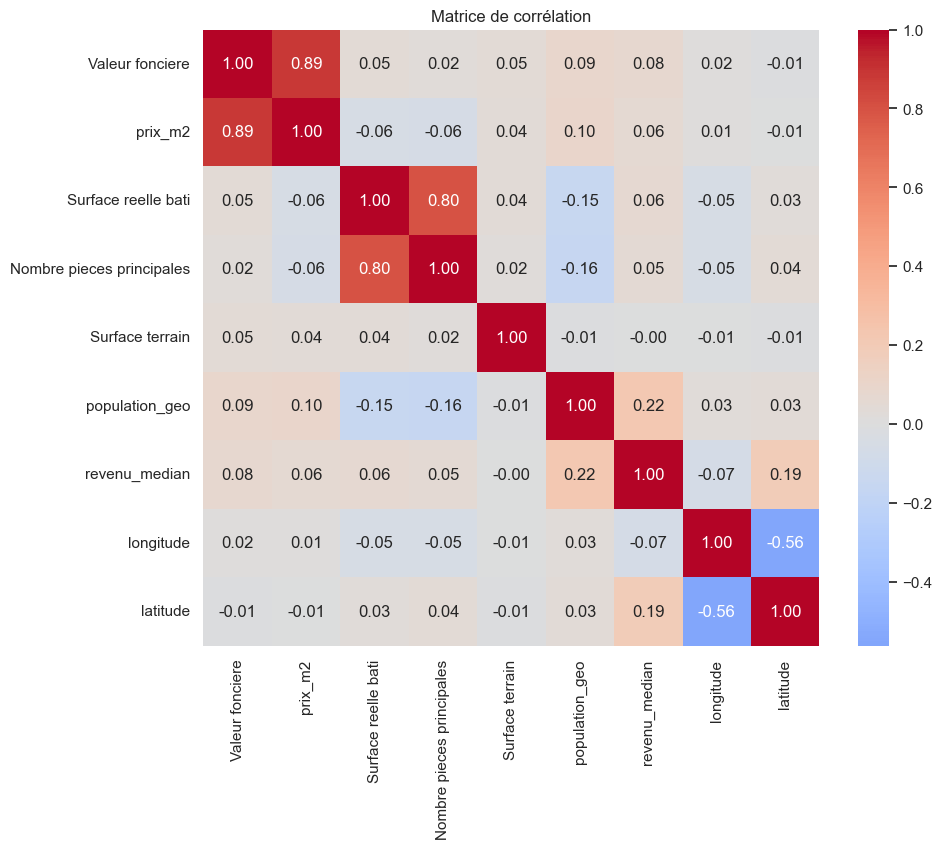

In [10]:
# On ne garde que les vraies variables numériques (pas les codes qui sont des catégories)
cols_num = [
    "Valeur fonciere", "prix_m2", "Surface reelle bati",
    "Nombre pieces principales", "Surface terrain",
    "population_geo", "revenu_median", "longitude", "latitude",
]

corr = df[cols_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation")
plt.show()


C:\Users\steph\AppData\Local\Temp\ipykernel_85140\3119175008.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_prix.values, y=corr_prix.index, palette="coolwarm")


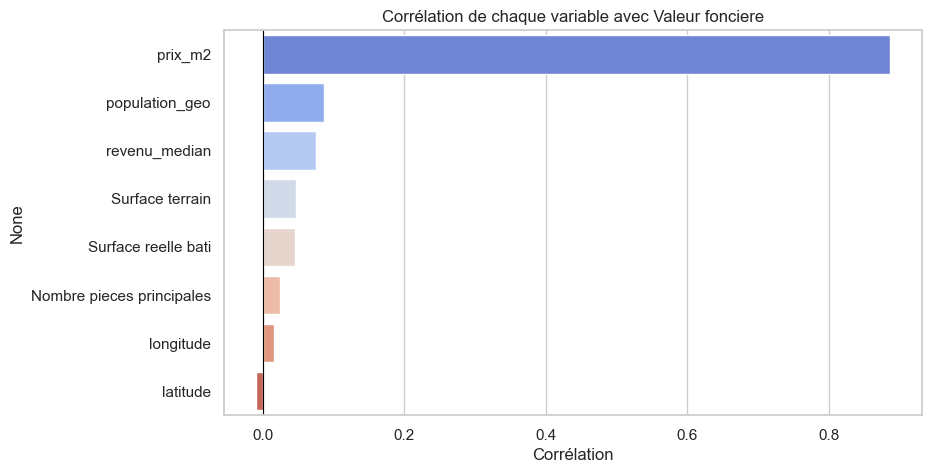

prix_m2                      0.89
population_geo               0.09
revenu_median                0.08
Surface terrain              0.05
Surface reelle bati          0.05
Nombre pieces principales    0.02
longitude                    0.02
latitude                    -0.01
Name: Valeur fonciere, dtype: float64

In [11]:
corr_prix = (
    df[cols_num].corr()["Valeur fonciere"]
    .drop("Valeur fonciere")
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=corr_prix.values, y=corr_prix.index, palette="coolwarm")
plt.title("Corrélation de chaque variable avec Valeur fonciere")
plt.xlabel("Corrélation")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

corr_prix


C:\Users\steph\AppData\Local\Temp\ipykernel_85140\2740131088.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_log.values, y=corr_log.index, palette="coolwarm")


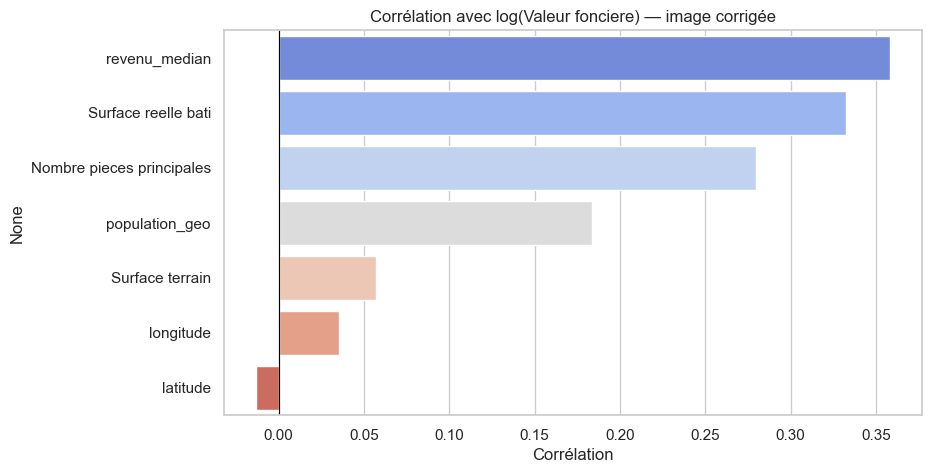

revenu_median                0.36
Surface reelle bati          0.33
Nombre pieces principales    0.28
population_geo               0.18
Surface terrain              0.06
longitude                    0.04
latitude                    -0.01
Name: log_valeur, dtype: float64

In [12]:
# On crée une version log de la cible, juste pour l'analyse
df_corr = df[cols_num].copy()
df_corr["log_valeur"] = np.log1p(df_corr["Valeur fonciere"])

# Corrélation de chaque variable avec la cible LOG (on retire les cibles elles-mêmes)
corr_log = (
    df_corr.corr()["log_valeur"]
    .drop(["log_valeur", "Valeur fonciere", "prix_m2"])
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=corr_log.values, y=corr_log.index, palette="coolwarm")
plt.title("Corrélation avec log(Valeur fonciere) — image corrigée")
plt.xlabel("Corrélation")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

corr_log


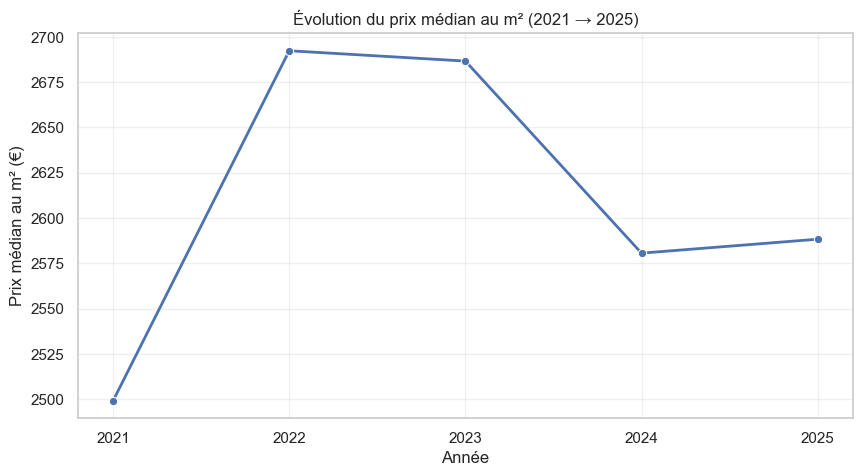

annee
2021   2,499.21
2022   2,692.31
2023   2,686.62
2024   2,580.65
2025   2,588.33
Name: prix_m2, dtype: float64

In [13]:
prix_annee = df.groupby("annee")["prix_m2"].median()

plt.figure(figsize=(10, 5))
sns.lineplot(x=prix_annee.index, y=prix_annee.values, marker="o", linewidth=2)
plt.title("Évolution du prix médian au m² (2021 → 2025)")
plt.xlabel("Année")
plt.ylabel("Prix médian au m² (€)")
plt.xticks(prix_annee.index)          # que des années entières, pas 2021.5
plt.grid(True, alpha=0.3)
plt.show()

prix_annee


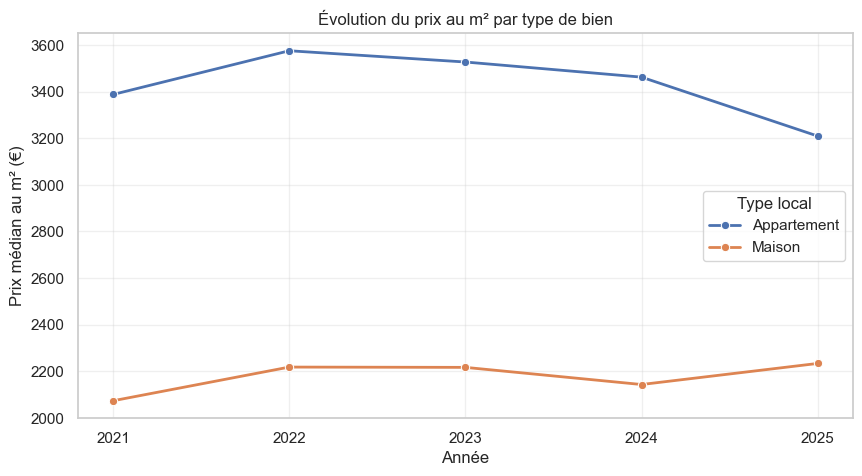

In [14]:
prix_annee_type = df.groupby(["annee", "Type local"])["prix_m2"].median().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=prix_annee_type, x="annee", y="prix_m2",
             hue="Type local", marker="o", linewidth=2)
plt.title("Évolution du prix au m² par type de bien")
plt.xlabel("Année")
plt.ylabel("Prix médian au m² (€)")
plt.xticks(prix_annee_type["annee"].unique())
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
df["annee"].value_counts().sort_index()

annee
2021    54242
2022    52071
2023    40480
2024    36778
2025    16429
Name: count, dtype: int64

conclusions : « 2025 est partiellement renseigné (délai de publication DVF), sa tendance est indicative. » On garde 2025 pour l'entraînement (plus de données = mieux), mais on le mentionne comme limite. Le jury appréciera cette lucidité

## 🧾 Conclusions de l'EDA

### Dataset
- ~5,6 M transactions (2021–2025), EDA menée sur échantillon aléatoire de 200k.
- Données propres : seule `Surface terrain` a des manquants (normal : appartements sans terrain).

### Cible
- **Cible retenue : `Valeur fonciere`, transformée en log** (skew 28 → 0,31).
- ⚠️ `prix_m2` à SUPPRIMER des features → fuite de données (dérivée du prix).

### Facteurs de prix (corrélation sur cible log)
- `revenu_median` (0,36) et `Surface reelle bati` = principaux moteurs.
- Localisation très déterminante : Top départements = 75, 92, 94.

### Métier
- Appartements plus chers au m² que les maisons.
- Revenus de la commune ↔ prix : lien positif modéré (oui, ça influence).
- Prix en baisse 2022→2024 (hausse des taux). 2025 incomplet → prudence.

### À faire au préprocessing (notebook 02)
- Supprimer `prix_m2` (fuite) + colonnes redondantes (`code_commune_geo`, `nom_commune_geo`, `Commune`, `codeDepartement`...).
- Traiter `Surface terrain` manquant (→ 0 pour les appartements).
- Encoder les catégorielles (`Type local`, `Code departement`).
- Appliquer `log1p` sur la cible.
